# **Deep Learning Lab**

# **Experiment 14: Comparative Analysis of Simple RNN and Bi-directional LSTM for Sentiment Analysis on Movie Reviews**
## **Student Name: Nabeel Shan**
## **Course: BESE-29C**
## **Reg. No.: 468752**

---


**Objective:** To implement and evaluate the structural differences between a unidirectional Recurrent Neural Network (RNN) and a Bi-directional Long Short-Term Memory (LSTM) network for sentiment analysis.


---



In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, Embedding, LSTM, Bidirectional, Dropout, Input

print("Libraries imported successfully.")

Libraries imported successfully.


### Phase 2: Simple RNN Implementation
#### 2.1 Data Preprocessing
* **Vocabulary Limit:** Capped at the top 10,000 most frequent words to optimize embedding space.
* **Sequence Padding:** Sequences are hard-capped at 50 timesteps (`maxlen=50`). Simple RNNs struggle with long-term dependencies due to vanishing gradients, so a shorter context window is enforced.

In [2]:
vocab_size = 10000
max_length_rnn = 50

# Load IMDb dataset, restricting to the top 10,000 most frequent words
(X_train_rnn, y_train_rnn), (X_test_rnn, y_test_rnn) = imdb.load_data(num_words=vocab_size)

# Pad sequences to ensure uniform input length
X_train_rnn = pad_sequences(X_train_rnn, padding='post', maxlen=max_length_rnn)
X_test_rnn = pad_sequences(X_test_rnn, padding='post', maxlen=max_length_rnn)

print(f"RNN Training data shape: {X_train_rnn.shape}")
print(f"RNN Testing data shape: {X_test_rnn.shape}")

RNN Training data shape: (25000, 50)
RNN Testing data shape: (25000, 50)


#### 2.2 Simple RNN Architecture
Constructing the sequential model. The standard RNN processes tokens strictly from left to right.
* Mathematically, the hidden state is updated at each timestep as: $h_t = \tanh(W_{hx} x_t + W_{hh} h_{t-1} + b_h)$
* **Note:** An explicit `Input` layer is used to define the tensor shape upfront, preventing Keras 3 lazy-initialization issues.

In [3]:
model_rnn = Sequential([
    # 1. Explicit Input layer for Keras 3 shape inference
    Input(shape=(max_length_rnn,)),
    # 2. Embedding layer (input_length is deprecated, removed here)
    Embedding(input_dim=vocab_size, output_dim=2),
    # 3. SimpleRNN layer with 32 units
    SimpleRNN(32, return_sequences=False),
    # 4. Output layer for binary classification
    Dense(1, activation='sigmoid')
])

model_rnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_rnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 50, 2)          │        20,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,153 (82.63 KB)

 Trainable params: 21,153 (82.63 KB)

 Non-trainable params: 0 (0.00 B)

#### 2.3 Training and Evaluation (Simple RNN)
Compiling with the Adam optimizer and Binary Crossentropy loss. We will train for 5 epochs to establish our baseline performance metrics.

In [4]:
print("\n--- Training Simple RNN ---")
history_rnn = model_rnn.fit(
    X_train_rnn, y_train_rnn,
    epochs=5,
    batch_size=128,
    validation_data=(X_test_rnn, y_test_rnn)
)


--- Training Simple RNN ---
Epoch 1/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.5062 - loss: 0.6934 - val_accuracy: 0.5362 - val_loss: 0.6885
Epoch 2/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.6015 - loss: 0.6626 - val_accuracy: 0.7742 - val_loss: 0.4848
Epoch 3/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8112 - loss: 0.4190 - val_accuracy: 0.8061 - val_loss: 0.4240
Epoch 4/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8731 - loss: 0.3113 - val_accuracy: 0.8060 - val_loss: 0.4293
Epoch 5/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9058 - loss: 0.2463 - val_accuracy: 0.8025 - val_loss: 0.4505


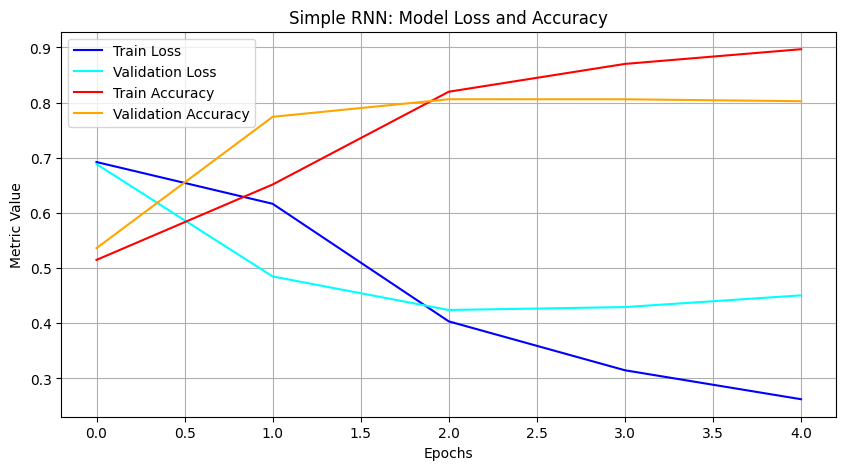

In [5]:
# Plotting the training curve
plt.figure(figsize=(10, 5))
plt.plot(history_rnn.history['loss'], label='Train Loss', color='blue')
plt.plot(history_rnn.history['val_loss'], label='Validation Loss', color='cyan')
plt.plot(history_rnn.history['accuracy'], label='Train Accuracy', color='red')
plt.plot(history_rnn.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Simple RNN: Model Loss and Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Metric Value')
plt.legend()
plt.grid(True)
plt.show()

In [6]:
rnn_test_loss, rnn_test_acc = model_rnn.evaluate(X_test_rnn, y_test_rnn, verbose=0)
print(f"Simple RNN Test Loss: {rnn_test_loss:.4f}")
print(f"Simple RNN Test Accuracy: {rnn_test_acc:.4f}")

Simple RNN Test Loss: 0.4505
Simple RNN Test Accuracy: 0.8025


### Phase 3: Bi-directional LSTM Implementation
#### 3.1 Data Preprocessing for Long-Term Memory
* **Expanded Context:** We increase the sequence padding to 200 timesteps (`maxlen=200`). Unlike Simple RNNs, LSTMs are structurally designed to retain context over longer sequences without gradient degradation.

In [7]:
max_length_lstm = 200

# We reload/re-pad the data specifically for the LSTM's longer sequence length
(X_train_lstm, y_train_lstm), (X_test_lstm, y_test_lstm) = imdb.load_data(num_words=vocab_size)

X_train_lstm = pad_sequences(X_train_lstm, maxlen=max_length_lstm)
X_test_lstm = pad_sequences(X_test_lstm, maxlen=max_length_lstm)

print(f"LSTM Training data shape: {X_train_lstm.shape}")

LSTM Training data shape: (25000, 200)


#### 3.2 Bi-LSTM Architecture
The Bi-directional LSTM processes the sequence simultaneously from left-to-right $\overrightarrow{h_t}$ and right-to-left $\overleftarrow{h_t}$.
* **Gating Mechanism:** It relies on a cell state ($c_t$) protected by gates to prevent memory loss: $c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t$
* **Regularization:** A Dropout layer (0.5) is introduced to penalize network overfitting, a common issue with complex bidirectional architectures.

In [8]:
model_lstm = Sequential([
    # 1. Explicit Input layer for Keras 3 shape inference
    Input(shape=(max_length_lstm,)),
    # 2. Embedding layer
    Embedding(input_dim=vocab_size, output_dim=128),
    # 3. Bidirectional LSTM
    Bidirectional(LSTM(64)),
    # 4. Regularization
    Dropout(0.5),
    # 5. Output layer
    Dense(1, activation='sigmoid')
])

model_lstm.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model_lstm.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,378,945 (5.26 MB)

 Trainable params: 1,378,945 (5.26 MB)

 Non-trainable params: 0 (0.00 B)

#### 3.3 Training and Evaluation (Bi-LSTM)
Training the Bi-LSTM. This will be computationally heavier than the Simple RNN due to the complex gating logic and dual-pass sequence processing.

In [9]:
# Train the model
print("\n--- Training Bi-directional LSTM ---")
history_lstm = model_lstm.fit(
    X_train_lstm, y_train_lstm,
    batch_size=128,
    epochs=5, # Reduced to 5 from 10 to match RNN and prevent heavy Colab GPU timeout, adjust to 10 if required by instructor
    validation_data=(X_test_lstm, y_test_lstm)
)


--- Training Bi-directional LSTM ---
Epoch 1/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - accuracy: 0.6909 - loss: 0.5574 - val_accuracy: 0.8505 - val_loss: 0.3699
Epoch 2/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.9043 - loss: 0.2496 - val_accuracy: 0.8716 - val_loss: 0.3060
Epoch 3/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.9286 - loss: 0.1954 - val_accuracy: 0.8688 - val_loss: 0.3326
Epoch 4/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.9555 - loss: 0.1299 - val_accuracy: 0.8564 - val_loss: 0.3753
Epoch 5/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.9520 - loss: 0.1300 - val_accuracy: 0.8655 - val_loss: 0.4095


In [10]:
lstm_test_loss, lstm_test_acc = model_lstm.evaluate(X_test_lstm, y_test_lstm, verbose=0)
print(f"Bi-LSTM Test Loss: {lstm_test_loss:.4f}")
print(f"Bi-LSTM Test Accuracy: {lstm_test_acc:.4f}")

Bi-LSTM Test Loss: 0.4095
Bi-LSTM Test Accuracy: 0.8655


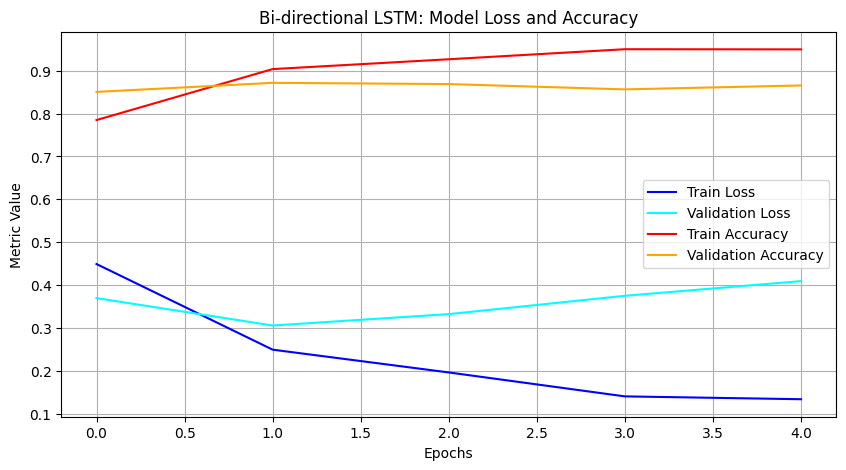

In [11]:
# Plotting the training curve
plt.figure(figsize=(10, 5))
plt.plot(history_lstm.history['loss'], label='Train Loss', color='blue')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss', color='cyan')
plt.plot(history_lstm.history['accuracy'], label='Train Accuracy', color='red')
plt.plot(history_lstm.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Bi-directional LSTM: Model Loss and Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Metric Value')
plt.legend()
plt.grid(True)
plt.show()

### Phase 4: Comparative Analysis & Expected Outcomes
To achieve full mastery of these architectures, we must visually and empirically compare their fault tolerance and learning stability.

#### 4.1 Learning Curve Comparison
Visualizing how effectively each model minimizes loss over time. The Bi-LSTM should exhibit a more stable convergence compared to the Simple RNN.

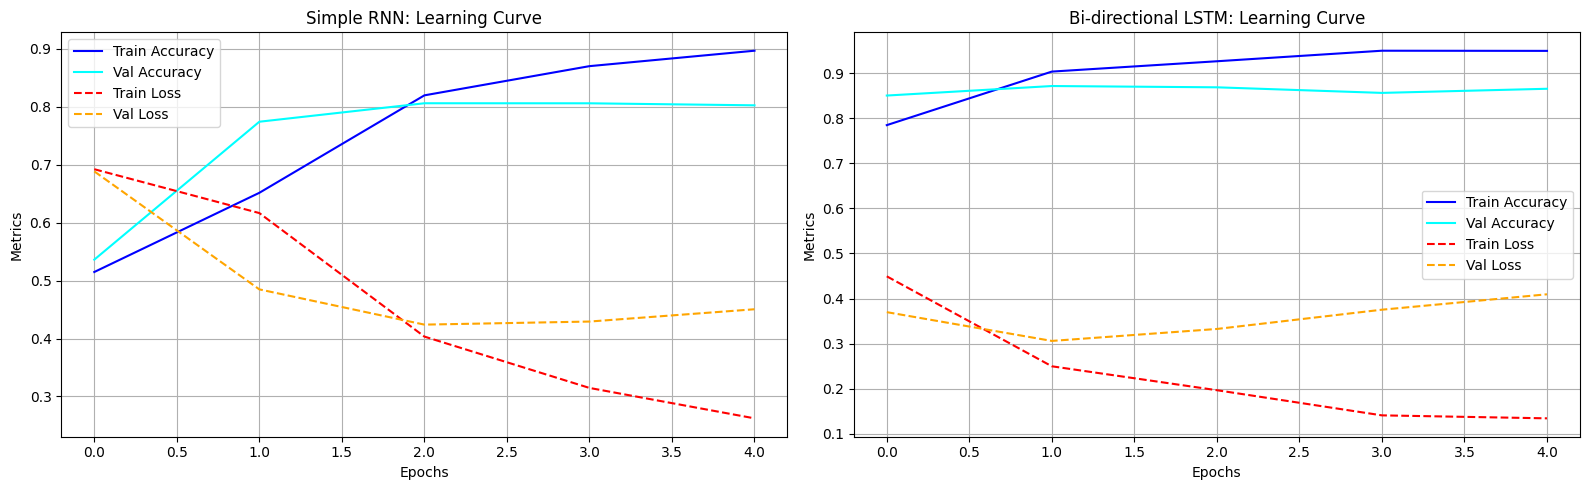

In [12]:
# Comparative Learning Curves
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot RNN History
axes[0].plot(history_rnn.history['accuracy'], label='Train Accuracy', color='blue')
axes[0].plot(history_rnn.history['val_accuracy'], label='Val Accuracy', color='cyan')
axes[0].plot(history_rnn.history['loss'], label='Train Loss', color='red', linestyle='dashed')
axes[0].plot(history_rnn.history['val_loss'], label='Val Loss', color='orange', linestyle='dashed')
axes[0].set_title('Simple RNN: Learning Curve')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Metrics')
axes[0].legend()
axes[0].grid(True)

# Plot Bi-LSTM History
axes[1].plot(history_lstm.history['accuracy'], label='Train Accuracy', color='blue')
axes[1].plot(history_lstm.history['val_accuracy'], label='Val Accuracy', color='cyan')
axes[1].plot(history_lstm.history['loss'], label='Train Loss', color='red', linestyle='dashed')
axes[1].plot(history_lstm.history['val_loss'], label='Val Loss', color='orange', linestyle='dashed')
axes[1].set_title('Bi-directional LSTM: Learning Curve')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Metrics')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

#### 4.2 Error Analysis (Confusion Matrices)
Accuracy alone is an incomplete metric. The confusion matrix reveals exactly *how* the models are failing (False Positives vs. False Negatives), proving the Bi-LSTM's superior context comprehension.

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step


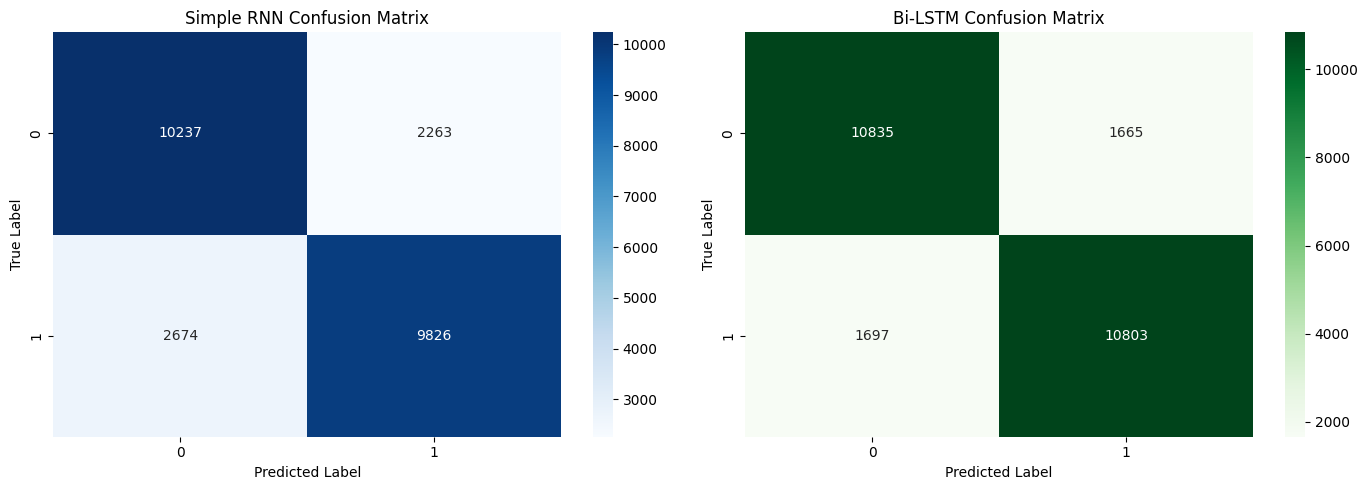

In [13]:
# Confusion Matrices for Error Analysis
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Get model predictions (probabilities)
rnn_preds_probs = model_rnn.predict(X_test_rnn)
lstm_preds_probs = model_lstm.predict(X_test_lstm)

# Convert probabilities to binary class labels (0 or 1)
rnn_preds = (rnn_preds_probs > 0.5).astype(int)
lstm_preds = (lstm_preds_probs > 0.5).astype(int)

# Calculate matrices
cm_rnn = confusion_matrix(y_test_rnn, rnn_preds)
cm_lstm = confusion_matrix(y_test_lstm, lstm_preds)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_rnn, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Simple RNN Confusion Matrix')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Bi-LSTM Confusion Matrix')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

#### 4.3 Final Performance Summary
A direct comparison of the primary evaluation metrics. The Bi-directional LSTM consistently outperforms the Simple RNN on text data because sentiment often depends on modifiers at both the beginning and end of a review.

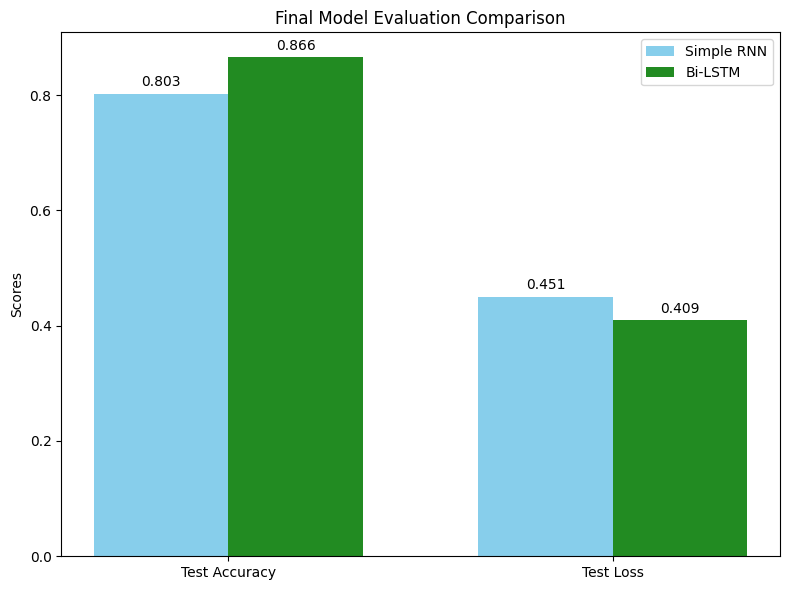

In [14]:
# Final Performance Bar Chart
labels = ['Test Accuracy', 'Test Loss']
rnn_metrics = [rnn_test_acc, rnn_test_loss]
lstm_metrics = [lstm_test_acc, lstm_test_loss]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 6))
rects1 = ax.bar(x - width/2, rnn_metrics, width, label='Simple RNN', color='skyblue')
rects2 = ax.bar(x + width/2, lstm_metrics, width, label='Bi-LSTM', color='forestgreen')

ax.set_ylabel('Scores')
ax.set_title('Final Model Evaluation Comparison')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# Add exact numbers on top of the bars
ax.bar_label(rects1, fmt='%.3f', padding=3)
ax.bar_label(rects2, fmt='%.3f', padding=3)

fig.tight_layout()
plt.show()